## UPDCREIT STOCK PRICE PREDICTION

In [1]:
## to change the name across the code
## ctrl + h will open the tab the fill the new name in replace
## to change the name across the entire code so you dont have to click enter everytime
## ctrl + shift + h

import pandas as pd

updcreit=pd.read_csv('../stock_data/updcreit.csv') ## so it can be small letter. This is cool.
updcreit=updcreit.drop(columns=['high_price','low_price'])
updcreit.rename(columns={'trade_date':'date'},inplace=True)
updcreit['date']=pd.to_datetime(updcreit['date'])
updcreit['month']=updcreit['date'].dt.month
updcreit['quarter']=updcreit['date'].dt.quarter
updcreit['year']=updcreit['date'].dt.year

updcreit

,id,symbol,date,open_price,close_price,volume,created_at,month,quarter,year
0,42788,UPDCREIT,2017-01-03,10.00,10.00,0,2026-04-08T02:41:25.765521+00:00,1,1,2017
1,43348,UPDCREIT,2017-01-04,10.00,10.00,0,2026-04-08T02:42:20.164398+00:00,1,1,2017
2,43458,UPDCREIT,2017-01-05,10.00,10.00,0,2026-04-08T02:42:22.380516+00:00,1,1,2017
3,43568,UPDCREIT,2017-01-06,10.00,10.00,0,2026-04-08T02:42:23.84796+00:00,1,1,2017
4,43658,UPDCREIT,2017-01-09,10.00,10.00,0,2026-04-08T02:42:26.938159+00:00,1,1,2017
...,...,...,...,...,...,...,...,...,...,...
2254,298153,UPDCREIT,2026-07-13,10.65,10.65,2864470,2026-07-13T15:10:02.995074+00:00,7,3,2026
2255,298591,UPDCREIT,2026-07-14,10.65,10.65,806851,2026-07-14T15:10:03.094441+00:00,7,3,2026
2256,299029,UPDCREIT,2026-07-15,10.65,10.65,861008,2026-07-15T15:10:03.078609+00:00,7,3,2026
2257,299467,UPDCREIT,2026-07-16,10.65,10.65,931163,2026-07-16T15:10:03.113936+00:00,7,3,2026


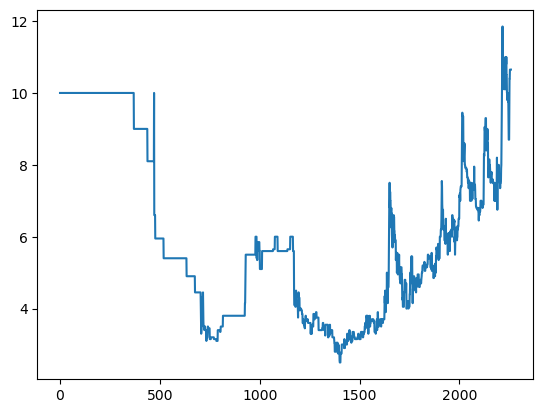

In [2]:
import matplotlib.pyplot as plt

plt.plot(updcreit['close_price'])
plt.show()

In [3]:
updcreit_end_month_df = (
    updcreit
    .sort_values("date")
    .groupby(updcreit["date"].dt.to_period("M"))
    .tail(1)
    .reset_index(drop=True)
)

updcreit_end_month_df

,id,symbol,date,open_price,close_price,volume,created_at,month,quarter,year
0,45358,UPDCREIT,2017-01-31,10.00,10.00,0,2026-04-08T02:43:03.07753+00:00,1,1,2017
1,47179,UPDCREIT,2017-02-28,10.00,10.00,4900,2026-04-08T02:44:45.006295+00:00,2,1,2017
2,49295,UPDCREIT,2017-03-31,10.00,10.00,0,2026-04-08T02:45:42.281198+00:00,3,1,2017
3,51123,UPDCREIT,2017-04-28,10.00,10.00,0,2026-04-08T02:51:55.619599+00:00,4,2,2017
4,53045,UPDCREIT,2017-05-31,10.00,10.00,0,2026-04-08T02:52:57.421655+00:00,5,2,2017
...,...,...,...,...,...,...,...,...,...,...
110,35390,UPDCREIT,2026-03-31,7.00,7.00,7689909,2026-03-31T15:00:02.085058+00:00,3,1,2026
111,281216,UPDCREIT,2026-04-30,7.50,7.50,2170888,2026-04-30T15:00:02.170664+00:00,4,2,2026
112,284282,UPDCREIT,2026-05-29,10.85,10.85,1114221,2026-05-29T15:00:02.455558+00:00,5,2,2026
113,294210,UPDCREIT,2026-06-30,9.75,9.75,784995,2026-06-30T15:10:03.08168+00:00,6,2,2026


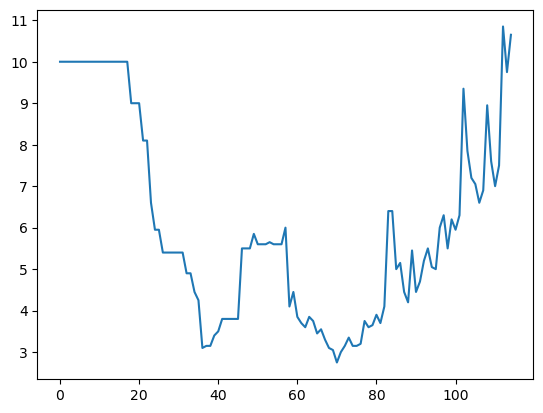

In [4]:
plt.plot(updcreit_end_month_df['close_price'])
plt.show()

In [5]:
updcreit_end_month_df['returns']=updcreit_end_month_df['close_price'].pct_change()*100
updcreit_end_month_df

,id,symbol,date,open_price,close_price,volume,created_at,month,quarter,year,returns
0,45358,UPDCREIT,2017-01-31,10.00,10.00,0,2026-04-08T02:43:03.07753+00:00,1,1,2017,NaN
1,47179,UPDCREIT,2017-02-28,10.00,10.00,4900,2026-04-08T02:44:45.006295+00:00,2,1,2017,0.000000
2,49295,UPDCREIT,2017-03-31,10.00,10.00,0,2026-04-08T02:45:42.281198+00:00,3,1,2017,0.000000
3,51123,UPDCREIT,2017-04-28,10.00,10.00,0,2026-04-08T02:51:55.619599+00:00,4,2,2017,0.000000
4,53045,UPDCREIT,2017-05-31,10.00,10.00,0,2026-04-08T02:52:57.421655+00:00,5,2,2017,0.000000
...,...,...,...,...,...,...,...,...,...,...,...
110,35390,UPDCREIT,2026-03-31,7.00,7.00,7689909,2026-03-31T15:00:02.085058+00:00,3,1,2026,-7.894737
111,281216,UPDCREIT,2026-04-30,7.50,7.50,2170888,2026-04-30T15:00:02.170664+00:00,4,2,2026,7.142857
112,284282,UPDCREIT,2026-05-29,10.85,10.85,1114221,2026-05-29T15:00:02.455558+00:00,5,2,2026,44.666667
113,294210,UPDCREIT,2026-06-30,9.75,9.75,784995,2026-06-30T15:10:03.08168+00:00,6,2,2026,-10.138249


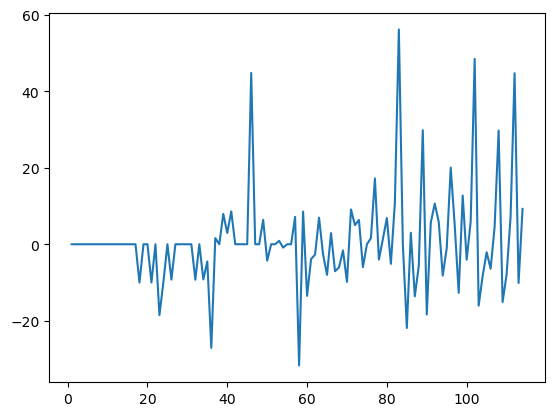

In [6]:
plt.plot(updcreit_end_month_df['returns'])
plt.show()

In [7]:
## Test stationarity

from statsmodels.tsa.stattools import adfuller

result = adfuller(updcreit_end_month_df['returns'].dropna())
print(result)
pvalue = result[1]
if pvalue < 0.05:
    print('stationary')
else:
    print('not stationary')

(-3.007605594342904, 0.034190212209919184, 5, 108, {'1%': -3.4924012594942333, '5%': -2.8886968193364835, '10%': -2.5812552709190673}, 807.4510949588586)
stationary


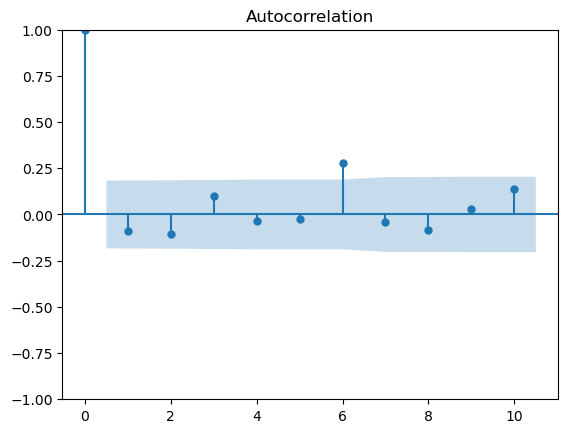

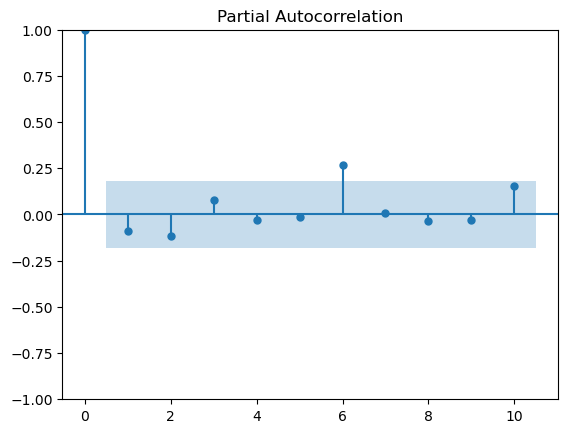

In [8]:
# Plotting the autocorrelation function and the partial autocorrelation function
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
plot_acf(updcreit_end_month_df['returns'].dropna(), lags=10)
plot_pacf(updcreit_end_month_df['returns'].dropna(), lags=10)
plt.show()

In [9]:
import random
random.seed(12345)

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import numpy as np
import warnings

warnings.filterwarnings('ignore')

train=updcreit_end_month_df['close_price'][:-10]
test=updcreit_end_month_df['close_price'][-10:]

# Grid Search on the SARIMA model
import numpy as np
scores = []
for p in range(3):
    for i in range(3):
        for q in range(3):
            for P in range(3):
                for D in range(3):
                    for Q in range(3):
                        try:
                            mod = SARIMAX(train, 
                            order=(p,i,q), seasonal_order=(P,D,Q,12))
                            res = mod.fit(disp=False)
                            fcst=res.forecast(steps=10)
                            score =  [p,i,q,P,D,Q,r2_score(test,fcst)]
                            print(score)
                            scores.append(score)
                            del mod
                            del res
                        except:
                            print('errored')


[0, 0, 0, 0, 0, 0, -28.86480377624289]
[0, 0, 0, 0, 0, 1, -10.156314267610963]
[0, 0, 0, 0, 0, 2, -11.396961417125915]
[0, 0, 0, 0, 1, 0, -1.537820249997372]
[0, 0, 0, 0, 1, 1, -1.4044292405988128]
[0, 0, 0, 0, 1, 2, -2.055439127325824]
[0, 0, 0, 0, 2, 0, -1.2582815571859909]
[0, 0, 0, 0, 2, 1, -1.03994324816377]
[0, 0, 0, 0, 2, 2, -0.2913078098453181]
[0, 0, 0, 1, 0, 0, -1.9911793246809424]
[0, 0, 0, 1, 0, 1, -1.855096868624917]
[0, 0, 0, 1, 0, 2, -2.481804602952342]
[0, 0, 0, 1, 1, 0, -1.4448609282107205]
[0, 0, 0, 1, 1, 1, -1.4504257029122392]
[0, 0, 0, 1, 1, 2, -1.8406534835888566]
[0, 0, 0, 1, 2, 0, -0.08405171787465426]
[0, 0, 0, 1, 2, 1, -0.8405779146594519]
[0, 0, 0, 1, 2, 2, -1.4447294707647402]
[0, 0, 0, 2, 0, 0, -1.889461498519545]
[0, 0, 0, 2, 0, 1, -1.8539929929675547]
[0, 0, 0, 2, 0, 2, -1.623899651570666]
[0, 0, 0, 2, 1, 0, -2.6396162707553588]
[0, 0, 0, 2, 1, 1, -2.425017185700432]
[0, 0, 0, 2, 1, 2, -1.173365961614898]
[0, 0, 0, 2, 2, 0, -1.8852495243794083]
[0, 0, 0, 

In [10]:
res = pd.DataFrame(scores)
res.columns = ['p', 'i', 'q', 'P', 'D', 'Q', 'score']
result = res.sort_values('score')
result

,p,i,q,P,D,Q,score
420,1,2,0,1,2,0,-44.766324
411,1,2,0,0,2,0,-43.454719
177,0,2,0,1,2,0,-36.658988
412,1,2,0,0,2,1,-34.162523
168,0,2,0,0,2,0,-32.863921
...,...,...,...,...,...,...,...
327,1,1,0,0,1,0,0.440889
219,0,2,2,0,1,0,0.444805
462,1,2,2,0,1,0,0.446142
435,1,2,1,0,1,0,0.452783


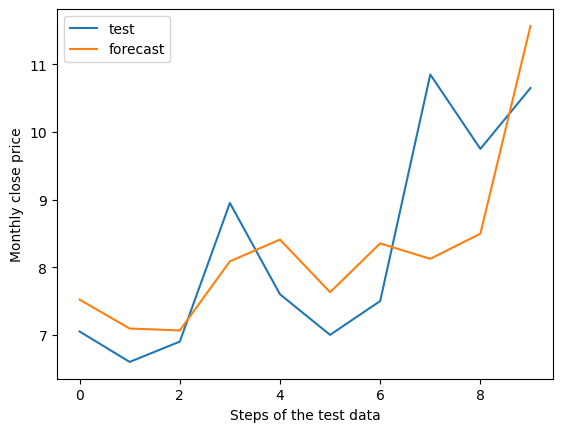

r2_score:  0.459181561904745
rmse:  1.134054569344645
description:  count    115.000000
mean       6.036087
std        2.409680
min        2.750000
25%        3.825000
50%        5.500000
75%        7.725000
max       10.850000
Name: close_price, dtype: float64


In [11]:
# Fitting a SARIMAX model with our best model 
# order=(2,0,1), seasonal_order=(1,2,1,10)

import random
random.seed(12345)
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np
import warnings

warnings.filterwarnings('ignore')

y_train=updcreit_end_month_df['close_price'][:-10]
y_test=updcreit_end_month_df['close_price'][-10:]

# scaler=StandardScaler()
# exog_train_scaled=scaler.fit_transform(X_full[:-10])
# exog_test_scaled=scaler.transform(X_full[-10:])

mod = SARIMAX(
y_train,
order=(0,2,1), 
seasonal_order=(0,1,0,12),
)

res = mod.fit(disp=False)
fcst = res.forecast(steps=10)

plt.plot(list(y_test))
plt.plot(list(fcst))
plt.xlabel('Steps of the test data')
plt.ylabel('Monthly close price')
plt.legend(['test', 'forecast'])
plt.show()
print('r2_score: ',r2_score(y_test, fcst))
print('rmse: ', np.sqrt(mean_squared_error(y_test,fcst)))
print('description: ', updcreit_end_month_df.close_price.describe())

We will work with this.